In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## EDA

### Initial exploration

When looking at data for the first time, try to get a high level of overview of things

In [30]:
cars = pd.read_csv("cardata.csv")
cars.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [31]:
# Look at the dimensionality of data
cars.shape

(11914, 16)

In [32]:
# Look for NAs
np.sum(cars.isna())

/opt/anaconda3/lib/python3.13/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

In [33]:
# Count number of NAs
cars.count()

Make                 11914
Model                11914
Year                 11914
Engine Fuel Type     11911
Engine HP            11845
Engine Cylinders     11884
Transmission Type    11914
Driven_Wheels        11914
Number of Doors      11908
Market Category       8172
Vehicle Size         11914
Vehicle Style        11914
highway MPG          11914
city mpg             11914
Popularity           11914
MSRP                 11914
dtype: int64

In [34]:
# Check the data types of columns
cars.dtypes

Make                  object
Model                 object
Year                   int64
Engine Fuel Type      object
Engine HP            float64
Engine Cylinders     float64
Transmission Type     object
Driven_Wheels         object
Number of Doors      float64
Market Category       object
Vehicle Size          object
Vehicle Style         object
highway MPG            int64
city mpg               int64
Popularity             int64
MSRP                   int64
dtype: object

Determine how many records we have associated with each car make. 

In [35]:
car_counts = cars["Make"].value_counts()
car_counts

Make
Chevrolet        1123
Ford              881
Volkswagen        809
Toyota            746
Dodge             626
Nissan            558
GMC               515
Honda             449
Mazda             423
Cadillac          397
Mercedes-Benz     353
Suzuki            351
BMW               334
Infiniti          330
Audi              328
Hyundai           303
Volvo             281
Subaru            256
Acura             252
Kia               231
Mitsubishi        213
Lexus             202
Buick             196
Chrysler          187
Pontiac           186
Lincoln           164
Oldsmobile        150
Land Rover        143
Porsche           136
Saab              111
Aston Martin       93
Plymouth           82
Bentley            74
Ferrari            69
FIAT               62
Scion              60
Maserati           58
Lamborghini        52
Rolls-Royce        31
Lotus              29
Tesla              18
HUMMER             17
Maybach            16
Alfa Romeo          5
McLaren             5
Spyke

Visualize this

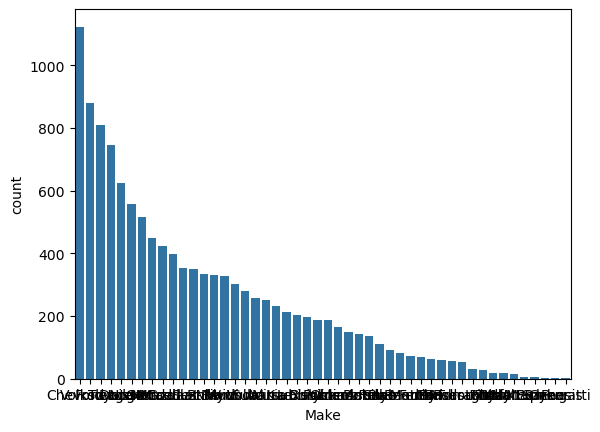

In [36]:
sns.barplot(x = car_counts.index, y = cars["Make"].value_counts());

Constrain the subset of values visualized

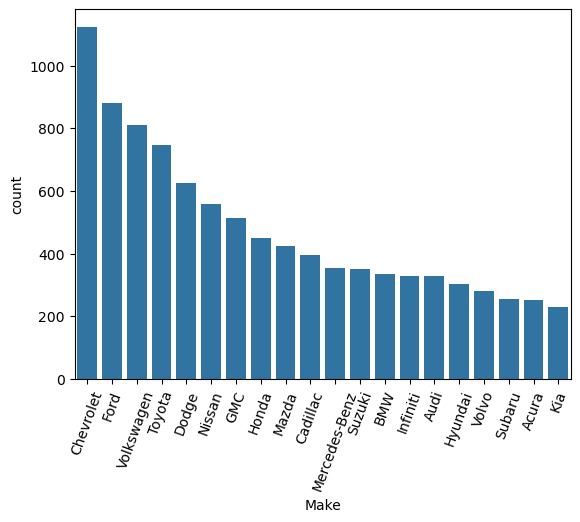

In [37]:
sns.barplot(x = car_counts.index[0:20], y = cars["Make"].value_counts()[0:20])
# Put the tick labels at an angle
plt.xticks(rotation=70);

<Axes: xlabel='count', ylabel='Make'>

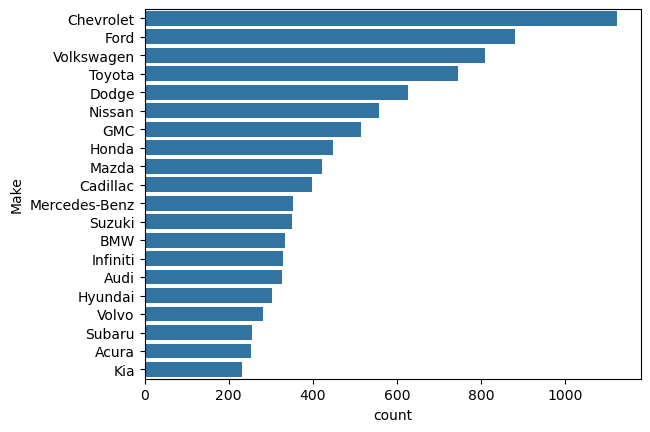

In [38]:
sns.barplot(y = car_counts.index[0:20], x = cars["Make"].value_counts()[0:20])

#### Exploring associations

Now let's look at the distributions of our numeric variables, as well as any associations between them.

In [39]:
# Drop variables we're uninterested in
cars_sub = cars.drop(["Number of Doors", "Engine Cylinders", "Year"], axis = 1)
cars_sub.columns

Index(['Make', 'Model', 'Engine Fuel Type', 'Engine HP', 'Transmission Type',
       'Driven_Wheels', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='object')

Now let's look at the distributions of our numeric variables, as well as any associations between them.

In [40]:
# Select only numeric columns in the data
cars_sub.select_dtypes(include=np.number)

,Engine HP,highway MPG,city mpg,Popularity,MSRP
0,335.0,26,19,3916,46135
1,300.0,28,19,3916,40650
2,300.0,28,20,3916,36350
3,230.0,28,18,3916,29450
4,230.0,28,18,3916,34500
...,...,...,...,...,...
11909,300.0,23,16,204,46120
11910,300.0,23,16,204,56670
11911,300.0,23,16,204,50620
11912,300.0,23,16,204,50920


Use bulk visualizations for a birds-eye view of the data

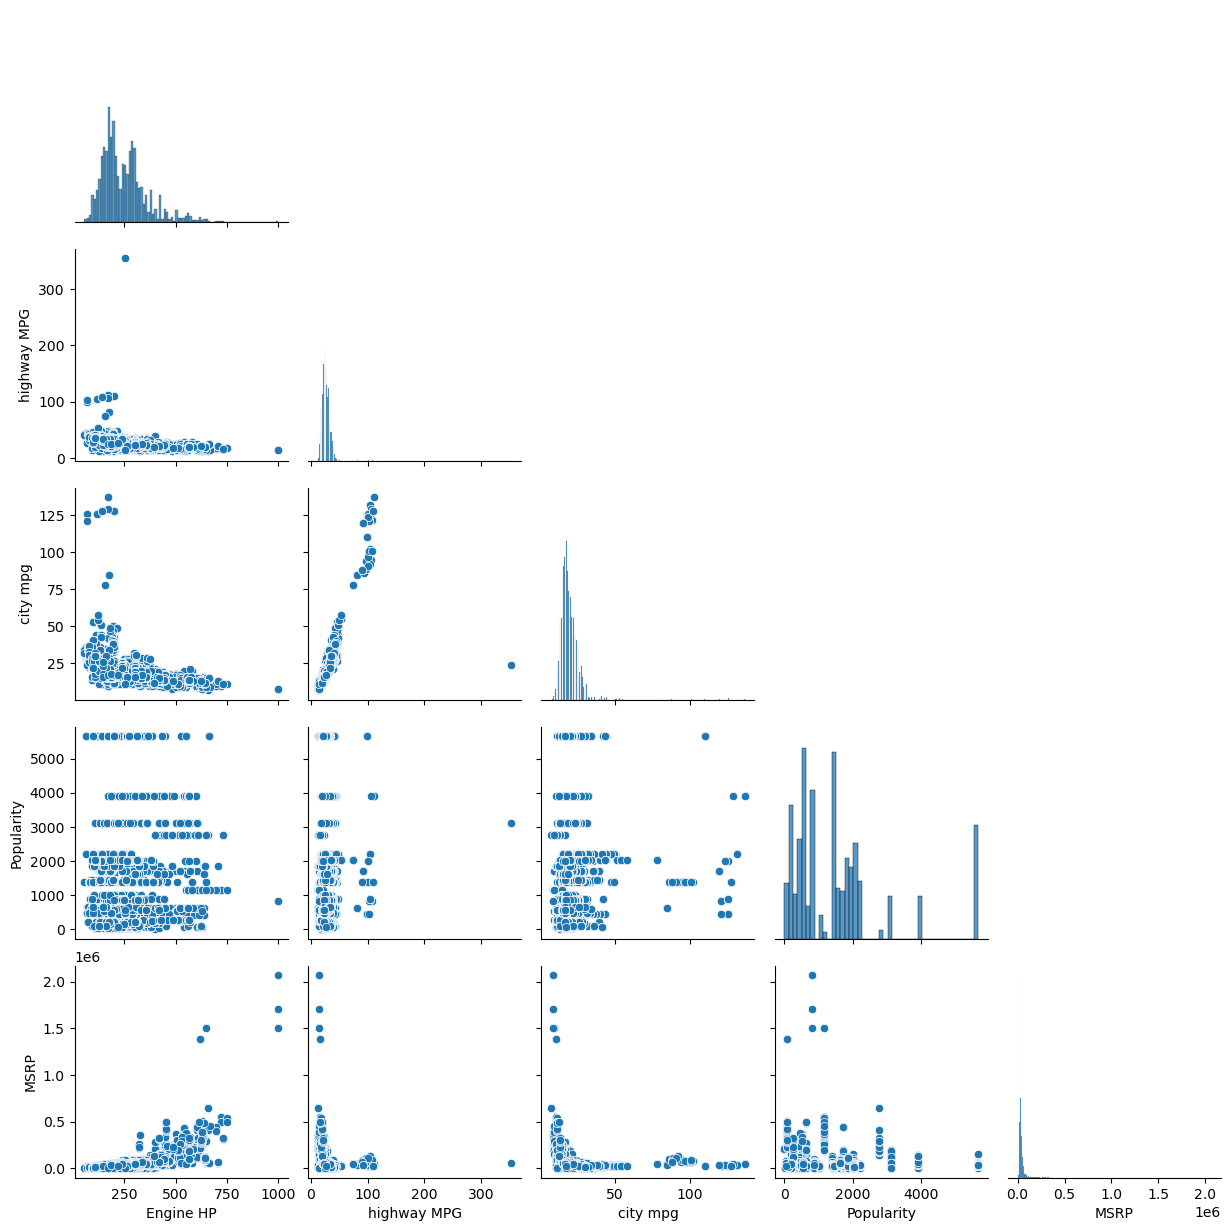

In [41]:
# Show pairwise association between each numeric variable
sns.pairplot(cars_sub.select_dtypes(include=np.number), corner = True)

**What are some things that you notice?**

Text(0, 0.5, 'Highway MPG')

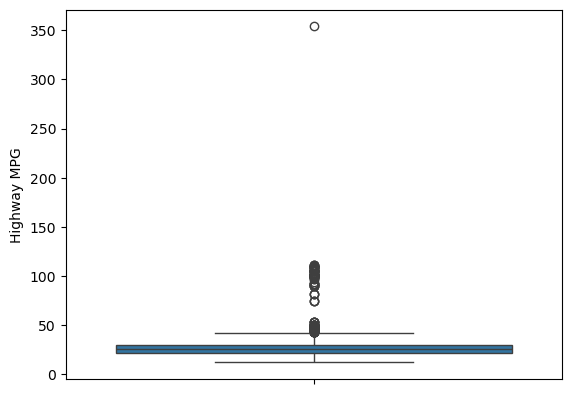

In [42]:
sns.boxplot(cars["highway MPG"])
plt.ylabel("Highway MPG")

In [43]:
cars[cars["highway MPG"] == np.max(cars["highway MPG"])]

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
1119,Audi,A6,2017,premium unleaded (recommended),252.0,4.0,AUTOMATED_MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,354,24,3105,51600


Also take a closer look at a few of the distributions

<Axes: xlabel='MSRP', ylabel='Count'>

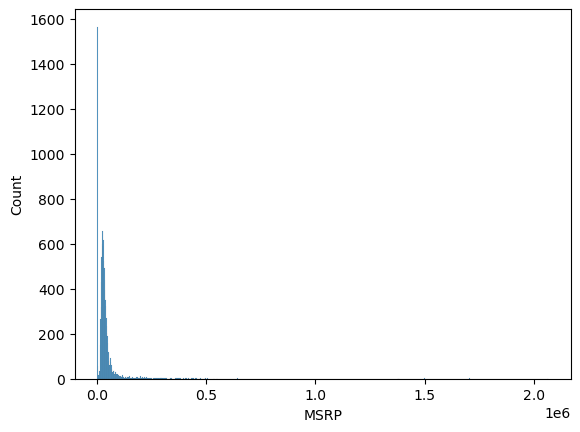

In [44]:
sns.histplot(cars["MSRP"])

<Axes: ylabel='MSRP'>

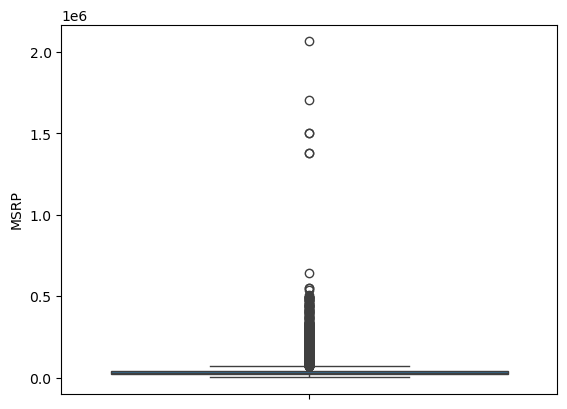

In [45]:
sns.boxplot(cars["MSRP"])

We're looking at a highly skewed distribution.

<Axes: xlabel='MSRP', ylabel='Count'>

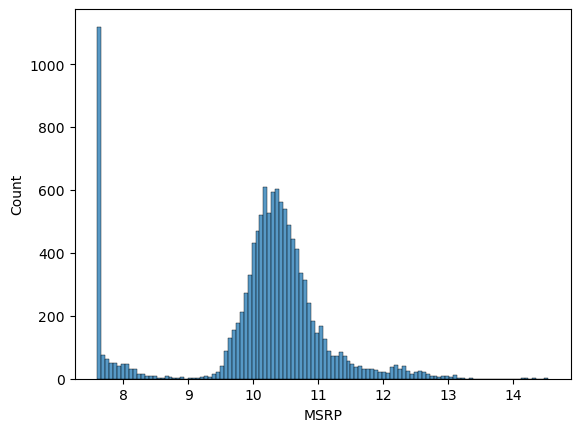

In [46]:
sns.histplot(np.log(cars["MSRP"]))

In [47]:
cars["MSRP"].sort_values(ascending = True)

8117        2000
744         2000
745         2000
746         2000
747         2000
          ...   
6351     1382750
11363    1500000
8486     1500000
11364    1705769
11362    2065902
Name: MSRP, Length: 11914, dtype: int64

A little strange but let's keep exploring the data

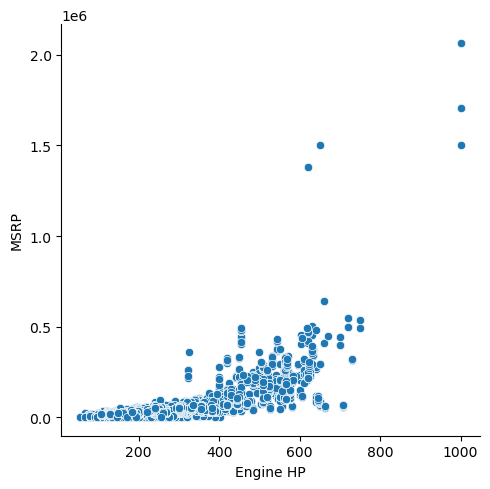

In [48]:
sns.relplot(data = cars, x = "Engine HP", y = "MSRP");

**What do you observe in this relationship?**

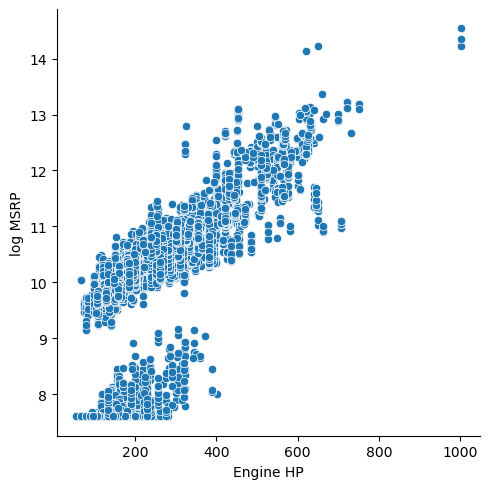

In [49]:
sns.relplot(x = cars["Engine HP"], y = np.log(cars["MSRP"]))
plt.ylabel("log MSRP");

Try to figure out what's going on with the weird grouping of data

In [50]:
cars[cars["MSRP"] < 9000].describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,1643.000000,1643.000000,1640.000000,1643.000000,1643.000000,1643.000000,1643.000000,1643.000000
mean,1994.786366,166.448570,5.548780,2.901400,23.278758,17.217894,1536.446135,2360.925746
std,3.023257,55.406693,1.498443,0.947471,5.363540,4.093606,1569.146455,807.940288
min,1990.000000,55.000000,3.000000,2.000000,12.000000,10.000000,26.000000,2000.000000
25%,1992.000000,125.000000,4.000000,2.000000,19.000000,15.000000,535.000000,2000.000000
50%,1994.000000,161.000000,6.000000,2.000000,23.000000,17.000000,873.000000,2000.000000
75%,1997.000000,200.000000,6.000000,4.000000,26.000000,19.000000,1851.000000,2347.500000
max,2000.000000,402.000000,12.000000,4.000000,44.000000,36.000000,5657.000000,8839.000000


**Which associated variable stands out as potentially unusual?** (Use the summary statistics)

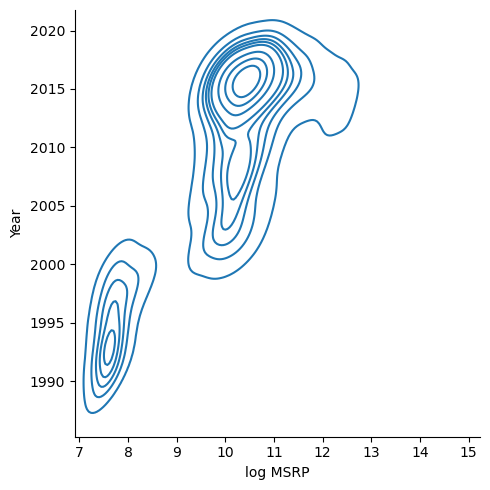

In [51]:
sns.displot(x = np.log(cars["MSRP"]), y = cars["Year"], kind = "kde")
plt.xlabel("log MSRP");

**What do you observe in this plot**?

## Working with text and datetimes

Read in data containing all police dispatches in Eugene from a certain timeframe

In [65]:
# Read in logs of eugene dispatches from January 1st 2022
dispatch = pd.read_excel("eugene_dispatches_25.csv.xlsx")
dispatch.head()

,call_time,dispatch_time,description,outcome,event_number,location
0,2025-10-22 13:27:34,2025-10-22 13:27:35,Traffic Stop,UNIFORM TRAFFIC CITATION ISSUED,25269765,"HWY 99N/ELMIRA RD, EUG"
1,2025-10-22 13:10:00,2025-10-22 13:10:00,Traffic Stop,UNIFORM TRAFFIC CITATION ISSUED,25269748,"HWY 99N/ROOSEVELT BLVD, EUG"
2,2025-10-22 12:48:39,2025-10-22 12:48:39,Traffic Stop,UNIFORM TRAFFIC CITATION ISSUED,25269722,"W 6TH AVE/GRANT ST, EUG"
3,2025-10-22 12:35:41,2025-10-22 12:51:45,Found Syringes,ASSISTED,25269709,"1360 FERRY ST, EUG"
4,2025-10-22 12:31:35,NaT,Theft,REPORT TAKEN,25269903,"568 N DANEBO AVE, EUG"


In [66]:
len(dispatch)

250

In [69]:
dispatch["call_time"]

0     2025-10-22 13:27:34
1     2025-10-22 13:10:00
2     2025-10-22 12:48:39
3     2025-10-22 12:35:41
4     2025-10-22 12:31:35
              ...        
245   2025-10-20 23:35:27
246   2025-10-20 23:11:58
247   2025-10-20 23:11:09
248   2025-10-20 23:09:13
249   2025-10-20 22:45:10
Name: call_time, Length: 250, dtype: datetime64[ns]

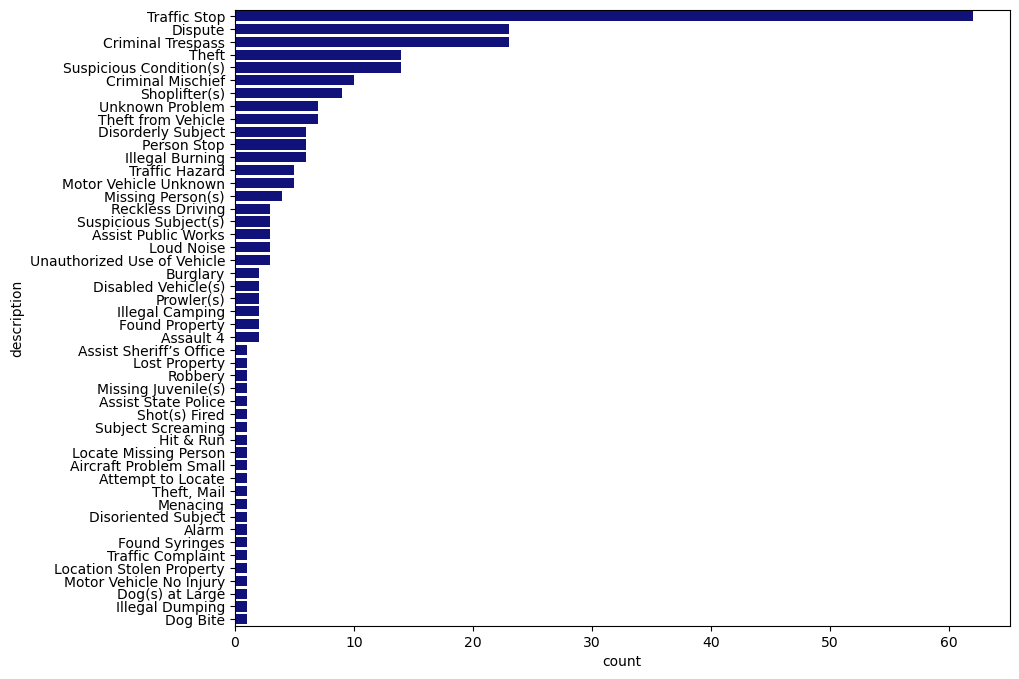

In [70]:
desc_counts = dispatch["description"].value_counts()

plt.figure(figsize=(10, 8))
sns.barplot(x= desc_counts, y=desc_counts.index, color = "darkblue");

In [71]:
dispatch[dispatch['description'].str.contains(r".*[tT]heft($|.*)", "Theft", regex = True)]

/var/folders/53/qn2bqxzd489fdf7zn6smrbtw0000gn/T/ipykernel_59594/1453457125.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  dispatch[dispatch['description'].str.contains(r".*[tT]heft($|.*)", "Theft", regex = True)]


,call_time,dispatch_time,description,outcome,event_number,location
4,2025-10-22 12:31:35,NaT,Theft,REPORT TAKEN,25269903,"568 N DANEBO AVE, EUG"
5,2025-10-22 12:31:35,NaT,Theft,REPORT TAKEN,25269875,"700 E BROADWAY, EUG"
9,2025-10-22 12:31:35,NaT,Theft,REPORT TAKEN,25269728,"959 TERRY ST, EUG"
15,2025-10-22 12:00:06,NaT,Theft,REPORT TAKEN,25269676,"580 E 17TH AVE, EUG"
22,2025-10-22 11:09:08,NaT,Theft,REPORT TAKEN,25269631,"790 E 22ND AVE, EUG"
27,2025-10-22 10:35:29,NaT,Theft,REPORT TAKEN,25269610,"1060 E 28TH AVE, EUG"
31,2025-10-22 10:07:30,NaT,Theft,REPORT TAKEN,25269585,"187 E 32ND AVE, EUG"
37,2025-10-22 09:45:45,NaT,Theft from Vehicle,REPORT TAKEN,25269569,"1759 FRANKLIN BLVD, EUG"
42,2025-10-22 09:04:06,NaT,Theft from Vehicle,REPORT TAKEN,25269528,"178 COMMONS DR, EUG"
54,2025-10-22 08:20:17,NaT,Theft,REPORT TAKEN,25269491,"744 THRONE DR, EUG"


In [82]:
dispatch["description"] = dispatch['description'].str.replace(r".*[tT]heft($|.*)", "Theft", regex = True)

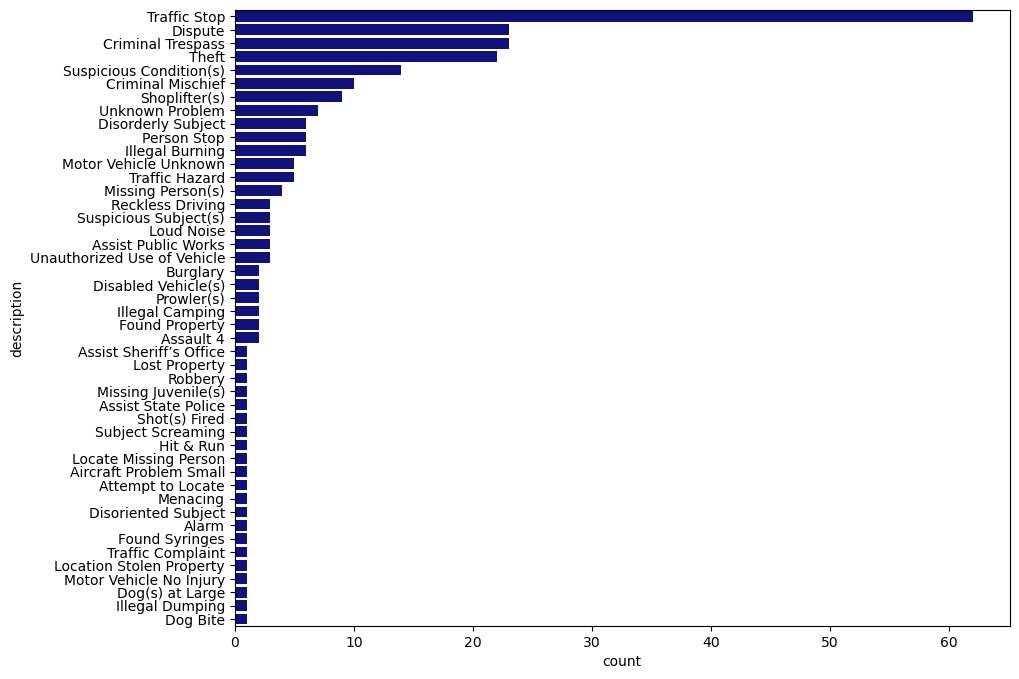

In [83]:
desc_counts = dispatch["description"].value_counts()

plt.figure(figsize=(10, 8))
sns.barplot(x= desc_counts, y=desc_counts.index, color = "darkblue");

Did any of these crimes happen nearby?

In [84]:
dispatch[dispatch["location"].str.contains(r"13TH|FRANKLIN|UNIVERSITY")]

,call_time,dispatch_time,description,outcome,event_number,location,call_time_dt,hour
7,2025-10-22 12:31:35,NaT,Criminal Mischief,REPORT TAKEN,25269817,"1747 W 13TH AVE, EUG",2025-10-22 12:31:35,12
10,2025-10-22 12:31:35,NaT,Criminal Mischief,REPORT TAKEN,25269704,"2117 FRANKLIN BLVD, EUG",2025-10-22 12:31:35,12
20,2025-10-22 11:32:54,2025-10-22 11:32:54,Assist Public Works,ASSISTED,25269650,"W 13TH AVE/ARTHUR ST, EUG",2025-10-22 11:32:54,11
37,2025-10-22 09:45:45,NaT,Theft,REPORT TAKEN,25269569,"1759 FRANKLIN BLVD, EUG",2025-10-22 09:45:45,9
110,2025-10-21 18:10:52,2025-10-21 20:10:02,Loud Noise,QUIET ON ARRIVAL,25269097,"3655 W 13TH AVE, EUG",2025-10-21 18:10:52,18
134,2025-10-21 15:06:01,2025-10-21 15:32:34,Unauthorized Use of Vehicle,RESOLVED,25268925,"E 13TH AVE/KINCAID ST, EUG",2025-10-21 15:06:01,15
169,2025-10-21 11:07:35,2025-10-21 11:39:42,Burglary,REPORT TAKEN,25268716,"W 13TH AVE/CHAMBERS ST, EUG",2025-10-21 11:07:35,11
199,2025-10-21 08:50:18,NaT,Theft,REPORT TAKEN,25268590,"1759 FRANKLIN BLVD, EUG",2025-10-21 08:50:18,8
245,2025-10-20 23:35:27,2025-10-20 23:41:02,Suspicious Subject(s),PATROL CHECK,25268379,"W 13TH AVE/POLK ST, EUG",2025-10-20 23:35:27,23


Let's use the date object to determine how 911 activity varies during the day.

In [75]:
dispatch["call_time_dt"] = pd.to_datetime(dispatch["call_time"], format = "%m/%d/%Y %H:%M")
dispatch.head

<bound method NDFrame.head of               call_time       dispatch_time            description  \
0   2025-10-22 13:27:34 2025-10-22 13:27:35           Traffic Stop   
1   2025-10-22 13:10:00 2025-10-22 13:10:00           Traffic Stop   
2   2025-10-22 12:48:39 2025-10-22 12:48:39           Traffic Stop   
3   2025-10-22 12:35:41 2025-10-22 12:51:45         Found Syringes   
4   2025-10-22 12:31:35                 NaT                  Theft   
..                  ...                 ...                    ...   
245 2025-10-20 23:35:27 2025-10-20 23:41:02  Suspicious Subject(s)   
246 2025-10-20 23:11:58 2025-10-20 23:29:15               Dog Bite   
247 2025-10-20 23:11:09 2025-10-20 23:13:41         Traffic Hazard   
248 2025-10-20 23:09:13                 NaT     Disorderly Subject   
249 2025-10-20 22:45:10 2025-10-20 22:48:40             Prowler(s)   

                             outcome  event_number  \
0    UNIFORM TRAFFIC CITATION ISSUED      25269765   
1    UNIFORM TRAFFIC 

In [76]:
np.min(dispatch["call_time_dt"])

Timestamp('2025-10-20 22:45:10')

In [77]:
np.max(dispatch["call_time_dt"])

Timestamp('2025-10-22 13:27:34')

In [78]:
np.mean(dispatch["call_time_dt"])

Timestamp('2025-10-21 18:28:56.344000')

In [79]:
dispatch["hour"] = dispatch["call_time_dt"].dt.hour
dispatch.head()

,call_time,dispatch_time,description,outcome,event_number,location,call_time_dt,hour
0,2025-10-22 13:27:34,2025-10-22 13:27:35,Traffic Stop,UNIFORM TRAFFIC CITATION ISSUED,25269765,"HWY 99N/ELMIRA RD, EUG",2025-10-22 13:27:34,13
1,2025-10-22 13:10:00,2025-10-22 13:10:00,Traffic Stop,UNIFORM TRAFFIC CITATION ISSUED,25269748,"HWY 99N/ROOSEVELT BLVD, EUG",2025-10-22 13:10:00,13
2,2025-10-22 12:48:39,2025-10-22 12:48:39,Traffic Stop,UNIFORM TRAFFIC CITATION ISSUED,25269722,"W 6TH AVE/GRANT ST, EUG",2025-10-22 12:48:39,12
3,2025-10-22 12:35:41,2025-10-22 12:51:45,Found Syringes,ASSISTED,25269709,"1360 FERRY ST, EUG",2025-10-22 12:35:41,12
4,2025-10-22 12:31:35,NaT,Theft,REPORT TAKEN,25269903,"568 N DANEBO AVE, EUG",2025-10-22 12:31:35,12


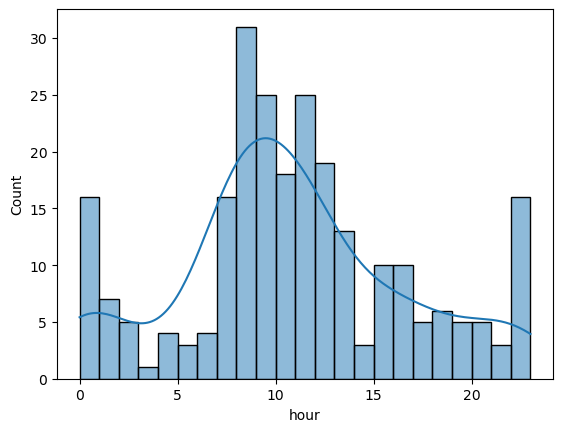

In [80]:
sns.histplot(dispatch["hour"], bins = np.arange(0,24,1), kde = True);

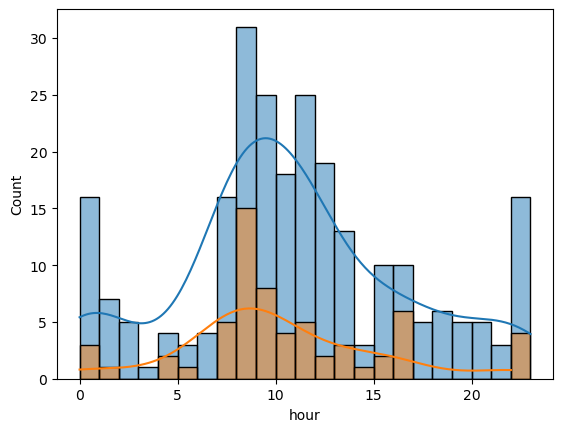

In [81]:
sns.histplot(dispatch["hour"], bins = np.arange(0,24,1), kde = True);
sns.histplot(dispatch[dispatch["description"] == "Traffic Stop"]["hour"], bins = np.arange(0,24,1), kde = True);